<div align="center">
<p align="center" style="width: 100%;">
    <img src="https://raw.githubusercontent.com/vlm-run/.github/refs/heads/main/profile/assets/vlm-black.svg" alt="VLM Run Logo" width="80" style="margin-bottom: -5px; color: #2e3138; vertical-align: middle; padding-right: 5px;"><br>
</p>
<p align="center"><a href="https://vlm.run"><b>Website</b></a> | <a href="https://docs.vlm.run/"><b>API Docs</b></a> | <a href="https://vlm.run/blog"><b>Blog</b></a> | <a href="https://discord.gg/AMApC2UzVY"><b>Discord</b></a>
</p>
</div>

# Orion-2: Multi-Schema Document Extraction

One agent execution. The `medical-multi-schema-extraction` skill **classifies the document, selects the matching schema, then extracts** — with grounding and confidence baked in.

| Step | What happens |
|---|---|
| **1. Classify** | Orion-2 labels the PDF as `referral`, `medical_record_request`, or `progress_note_office_visit` |
| **2. Select schema** | Loads **exactly one** schema from `schemas/<documentType>.json` |
| **3. Extract** | Runs `vlmrun.document.extract` with that schema, `grounding=True`, `confidence=True` |

You call `client.agent.execute` once. Schema selection is the skill's job — you do not pick the schema yourself.

We run the same handwritten physician referral form used in the Orion-2 migration cookbook. Expect `documentType="referral"` and the referral schema to be selected automatically.

**Docs:** [Code Execution](https://docs.vlm.run/agents/code-execution), [Executions](https://docs.vlm.run/skills/usage/agent)


---
## ⚙️ 1. Setup

Install the VLM Run SDK, plus `pypdfium2` (used by the SDK's `pdf_images` helper to render the pages).


In [ ]:
!pip install vlmrun --upgrade --quiet
!pip install pypdfium2 --quiet
!pip install pandas --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1

## 🔑 2. Load your API key

Add your `VLMRUN_API_KEY` to the Colab **Secrets** tab (🔑 icon, left sidebar), then load it below.


In [ ]:
import os

try:
    from google.colab import userdata
    VLMRUN_API_KEY = userdata.get("VLMRUN_API_KEY")
except (ImportError, Exception):
    import getpass
    VLMRUN_API_KEY = os.getenv("VLMRUN_API_KEY") or getpass.getpass("Enter your VLM Run API key: ")

assert VLMRUN_API_KEY, "Missing VLMRUN_API_KEY in environment or Colab Secrets."
print("✅ API key loaded")


Enter your VLM Run API key: ··········
✅ API key loaded


## 🧩 3. The multi-schema skill

Point at `medical-multi-schema-extraction`. Grounding and confidence live inside the skill pipeline — after it **selects** the schema for the detected document type, it extracts with `grounding=True` and `confidence=True`.

Uses the pinned skill version below. Update `skill_version` if you publish a newer revision.


In [9]:
from vlmrun.client.types import AgentSkill

SKILL = AgentSkill(
    skill_name="medical-multi-schema-extraction",
    skill_version="20260721-b7a8f565",
)

print("Skill:", SKILL.skill_name, SKILL.skill_version)
print("Schemas the skill can select:")
print("  • referral")
print("  • medical_record_request")
print("  • progress_note_office_visit")


Skill: medical-multi-schema-extraction 20260721-b7a8f565
Schemas the skill can select:
  • referral
  • medical_record_request
  • progress_note_office_visit


## 📄 4. The document: handwritten physician referral form

Download the form and preview page 1. The rasterized pages (`pdf_pages`) are reused later for the bounding-box overlays.

Because this is a referral, the skill should **select the referral schema** — not the record-request or progress-note schemas.


Downloaded multi-document.pdf | 5 page(s)



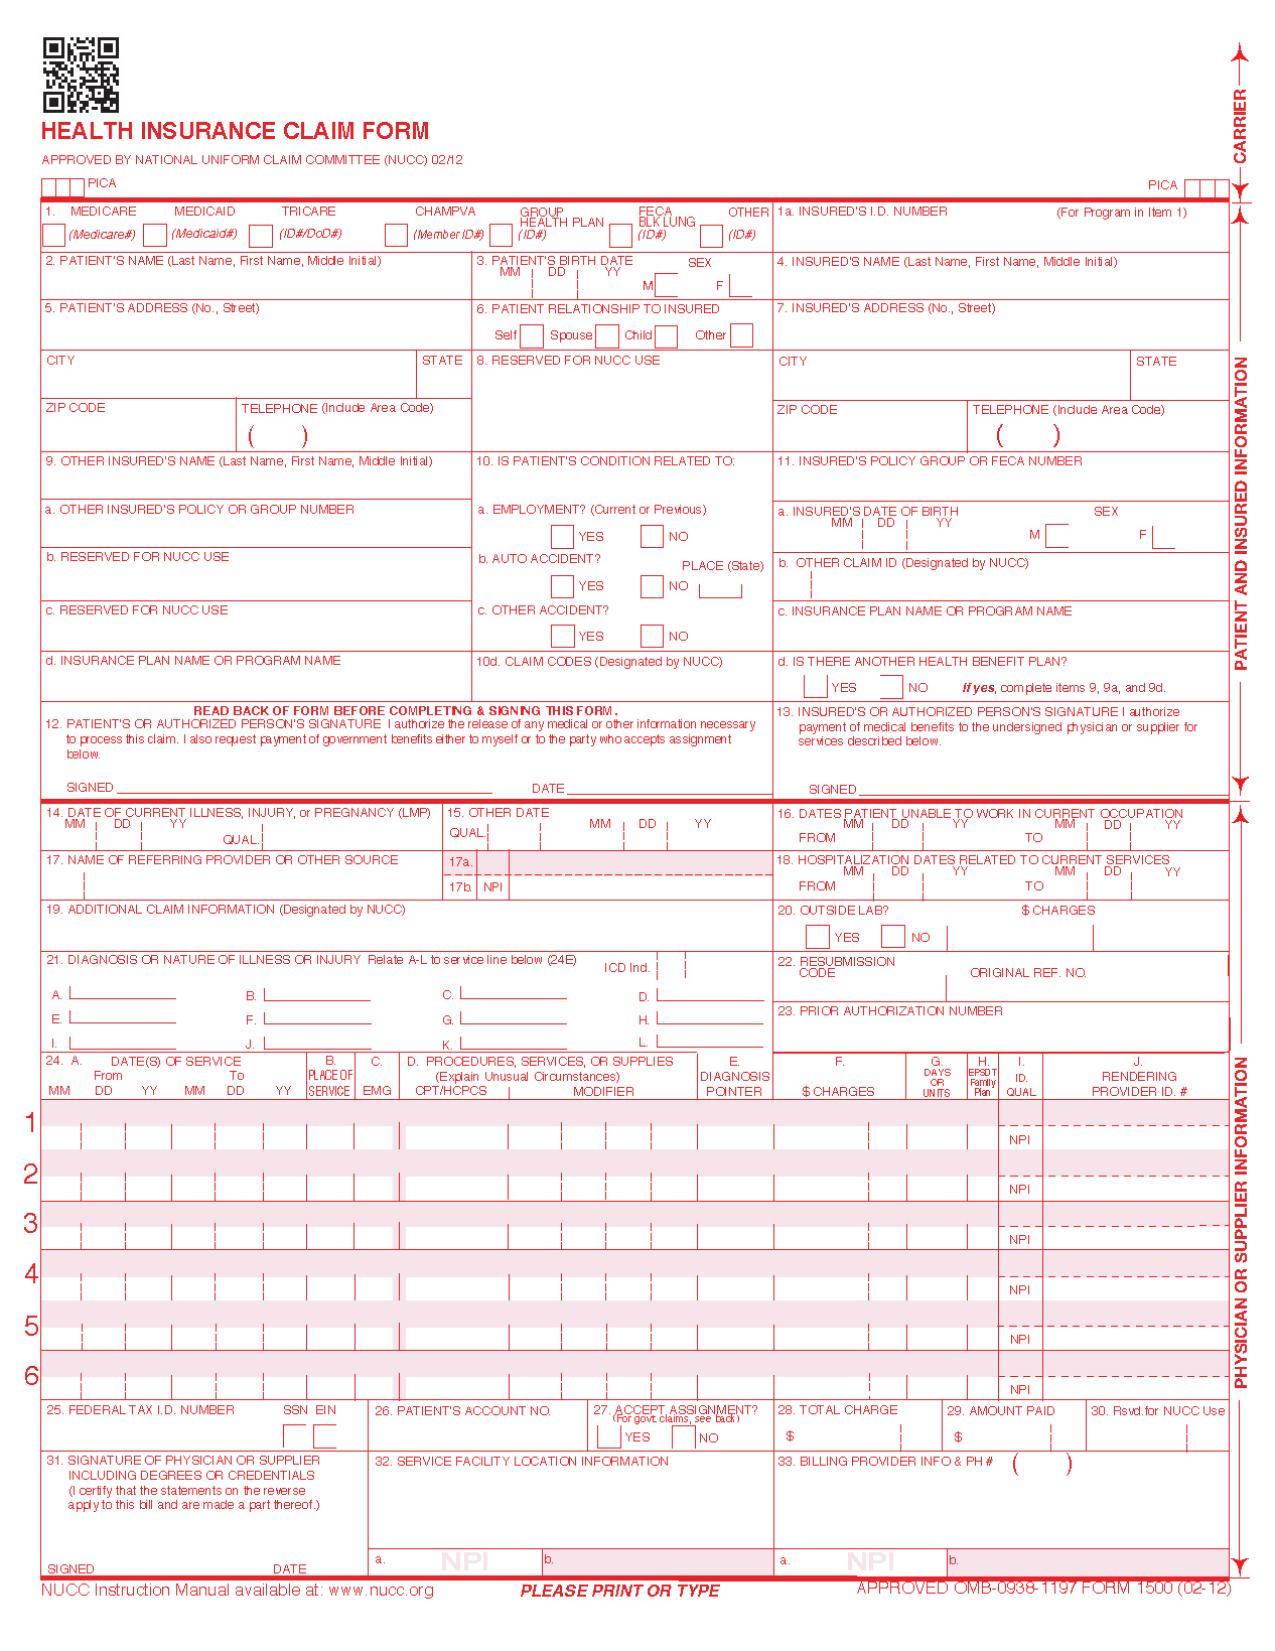

In [ ]:
import base64, requests
from io import BytesIO
from pathlib import Path
from IPython.display import HTML, display
from vlmrun.common.pdf import pdf_images  # SDK helper (pypdfium2 under the hood)


def show_image(img, caption="", width=560):
    """Show a PIL image inline, capped at `width` px so it fits nicely in Colab."""
    buf = BytesIO()
    img.convert("RGB").save(buf, format="JPEG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    tag = (f"<img src='data:image/jpeg;base64,{b64}' "
           f"style='max-width:{width}px; border:1px solid #eee; border-radius:6px'>")
    if caption:
        tag = (f"<div style='text-align:center'>{tag}"
               f"<div style='font-size:12px; color:#666; margin-top:4px'>{caption}</div></div>")
    display(HTML(tag))


REFERRAL_URL = "https://storage.googleapis.com/vlm-data-public-prod/hub/examples/healthcare.patient-referral/multi-document.pdf"
PDF_PATH = Path("/content/multi-document.pdf")
PDF_PATH.write_bytes(requests.get(REFERRAL_URL).content)

pdf_pages = list(pdf_images(PDF_PATH, dpi=150))
print(f"Downloaded {PDF_PATH.name} | {len(pdf_pages)} page(s)")
show_image(pdf_pages[0].image, caption="Physician referral form (page 1) → expect schema: referral", width=560)


---
## ✨ 5. One execution: classify → select schema → extract

Create the client, upload the PDF, then call `client.agent.execute` once. The skill:

1. Classifies the document type
2. **Selects** `schemas/<documentType>.json`
3. Extracts with grounding + confidence

`executions.wait` blocks until it finishes.


In [11]:
from pydantic import BaseModel, Field
from vlmrun.client import VLMRun
from vlmrun.types import MessageContent
from vlmrun.client.types import AgentExecutionConfig, AgentExecutionResponse

client = VLMRun(api_key=VLMRUN_API_KEY)
print("✅ Client ready → api.vlm.run")


class FileInput(BaseModel):
    file: MessageContent = Field(..., description="The file to process")


uploaded_file = client.files.upload(file=PDF_PATH)
print(f"Uploaded file ID: {uploaded_file.id}")

execution: AgentExecutionResponse = client.agent.execute(
    model="vlmrun-orion-2:pro",
    inputs=FileInput(
        file=MessageContent(type="input_file", file_id=uploaded_file.id),
    ),
    config=AgentExecutionConfig(skills=[SKILL], mode="program"),
    batch=True,
)
print(f"Execution ID: {execution.id} | status: {execution.status}")


✅ Client ready → api.vlm.run
Uploaded file ID: 62385448-235a-4ab0-a0a3-71cbf442fa74
Execution ID: 8ef9688b-592e-4904-9046-b17296dcfdc2 | status: enqueued


### 🧾 Wait & inspect — which schema was selected?

The skill returns something shaped like:

```json
{
  "skillUsed": "medical-referral-information-extraction",
  "documentType": "referral",
  "classificationRationale": "...",
  "data": { "pages": [ /* grounded extraction */ ] }
}
```

`documentType` is the schema-selection signal: it tells you which of the three schemas was loaded for this PDF.


In [12]:
from IPython.display import JSON

execution = client.executions.wait(execution.id, timeout=300)
print("✅ Status:", execution.status)

payload = execution.response or {}
JSON(payload) if payload else print("None")

# Schema selection summary (works whether the envelope is nested or flat)
def _find(obj, *keys):
    if isinstance(obj, dict):
        for k in keys:
            if k in obj:
                return obj[k]
        for v in obj.values():
            found = _find(v, *keys)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for v in obj:
            found = _find(v, *keys)
            if found is not None:
                return found
    return None

document_type = _find(payload, "documentType")
rationale = _find(payload, "classificationRationale")
skill_used = _find(payload, "skillUsed")

print()
print("── Schema selection ──")
print(f"documentType:              {document_type}")
print(f"schema selected:           schemas/{document_type}.json" if document_type else "schema selected:           (unknown)")
print(f"skillUsed (legacy label):  {skill_used}")
print(f"classificationRationale:   {rationale}")


✅ Status: completed

── Schema selection ──
documentType:              referral
schema selected:           schemas/referral.json
skillUsed (legacy label):  medical-referral-information-extraction
classificationRationale:   The document set contains various medical and insurance documents, concluding with a completed 'Physician Referral Form' on page 5, which outlines details of a referral from Dr. Irene Wong to Dr. Sam Yong for patient Kevin Chen.


In [13]:
import json
print(json.dumps(payload, indent=2, default=str))

{
  "skillUsed": "medical-referral-information-extraction",
  "documentType": "referral",
  "classificationRationale": "The document set contains various medical and insurance documents, concluding with a completed 'Physician Referral Form' on page 5, which outlines details of a referral from Dr. Irene Wong to Dr. Sam Yong for patient Kevin Chen.",
  "data": {
    "pages": [
      {
        "type": "referral",
        "patient": {
          "givenName": "Kevin",
          "familyName": "chen",
          "dateOfBirth": "2001-09-15",
          "givenName_metadata": {
            "confidence": "hi",
            "bboxes": [
              {
                "content": "Kevin",
                "bbox": {
                  "xywh": [
                    0.1915,
                    0.2012,
                    0.0879,
                    0.0254
                  ]
                },
                "page": 4,
                "confidence": 0.66
              }
            ]
          },
          "

### 🖼️ Visualize the grounding boxes

Grounding is still on — the selected schema's fields come back with `_metadata.bboxes`. The helpers below walk the payload and draw boxes on the page. Collapse this cell if you like.


In [14]:
# Visualization helpers (draw grounding boxes on the page).
from difflib import SequenceMatcher
from PIL import ImageDraw, ImageFont


def _font(size):
    for p in ("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"):
        try:
            return ImageFont.truetype(p, size)
        except Exception:
            pass
    try:
        return ImageFont.load_default(size=size)
    except TypeError:
        return ImageFont.load_default()


def _align(value, chunks):
    """Split a field's final value across its boxes (fuzzy), so each box shows its
    own slice of the value. Falls back to the raw OCR text only if there is no value."""
    if value is None:
        return [str(c or "") for c in chunks]
    final = str(value)
    if len(chunks) <= 1:
        return [final]
    low, anchors = final.lower(), []
    for c in chunks:
        cs = str(c or "").lower().strip()
        m = SequenceMatcher(None, low, cs, autojunk=False).find_longest_match(0, len(low), 0, len(cs)) if cs else None
        if not cs or m.size == 0:
            anchors = None
            break
        center, half = m.a + m.size // 2, max(len(cs) // 2, m.size // 2)
        anchors.append((max(0, center - half), min(len(final), center + half)))
    if anchors is None:                                  # even split fallback
        step = len(final) / len(chunks)
        return [final[int(i * step):int((i + 1) * step)].strip() for i in range(len(chunks))]
    order = sorted(range(len(anchors)), key=lambda i: anchors[i][0])
    sa = [anchors[i] for i in order]
    bounds = [0] + [(sa[i][1] + sa[i + 1][0]) // 2 for i in range(len(sa) - 1)] + [len(final)]

    def snap(idx):
        if idx <= 0 or idx >= len(final):
            return idx
        l, r = final.rfind(" ", 0, idx), final.find(" ", idx)
        if l == -1 and r == -1:
            return idx
        if l == -1:
            return r
        if r == -1:
            return l
        return l if idx - l <= r - idx else r

    bounds = [snap(b) for b in bounds]
    ordered = [final[bounds[i]:bounds[i + 1]].strip() for i in range(len(bounds) - 1)]
    out = [""] * len(chunks)
    for si, oi in enumerate(order):
        out[oi] = ordered[si]
    return out


def collect_bboxes(obj, path=""):
    """(field, page, xywh, label, value, confidence) for every grounded box.

    `value` is the final extracted value from the response (the sibling field of
    `<field>_metadata`), and `label` is that value drawn on the box, not the raw
    per-box OCR `content`. `confidence` is the field-level "hi"/"med"/"lo" score.
    """
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k.endswith("_metadata") and isinstance(v, dict) and v.get("bboxes"):
                field = k[:-len("_metadata")]
                value = obj.get(field)                     # final extracted value (sibling)
                conf = v.get("confidence")                 # field-level confidence
                items = [it for it in v["bboxes"]
                         if isinstance(it, dict) and (it.get("bbox") or {}).get("xywh")]
                labels = _align(value, [it.get("content", "") for it in items])
                fpath = f"{path}.{field}" if path else field
                for it, label in zip(items, labels):
                    out.append((fpath, it.get("page", 0), it["bbox"]["xywh"], label, value, conf))
            elif not k.endswith("_metadata"):
                out += collect_bboxes(v, f"{path}.{k}" if path else k)
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            out += collect_bboxes(v, f"{path}[{i}]")
    return out


def render_bboxes(bboxes, pages, width=560):
    """Draw the boxes on each rasterized page and show it (capped at `width`)."""
    for page in pages:
        idx = page.page_number
        boxes = [b for b in bboxes if b[1] == idx] or (bboxes if len(pages) == 1 else [])
        img = page.image.copy().convert("RGB")
        draw = ImageDraw.Draw(img)
        W, H = img.size
        font = _font(26)
        for field, _pg, (x, y, w, h), label, _value, _conf in boxes:
            x0, y0, x1, y1 = int(x * W), int(y * H), int((x + w) * W), int((y + h) * H)
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            text = str(label) if label else field.split(".")[-1]
            ly = max(0, y0 - 30)
            draw.rectangle(draw.textbbox((x0, ly), text, font=font), fill="red")
            draw.text((x0, ly), text, fill="white", font=font)
        show_image(img, caption=f"Page {idx + 1} ({len(boxes)} boxes)", width=width)


print("Visualization helpers loaded.")


Visualization helpers loaded.


Found 5 grounded boxes (schema='referral')



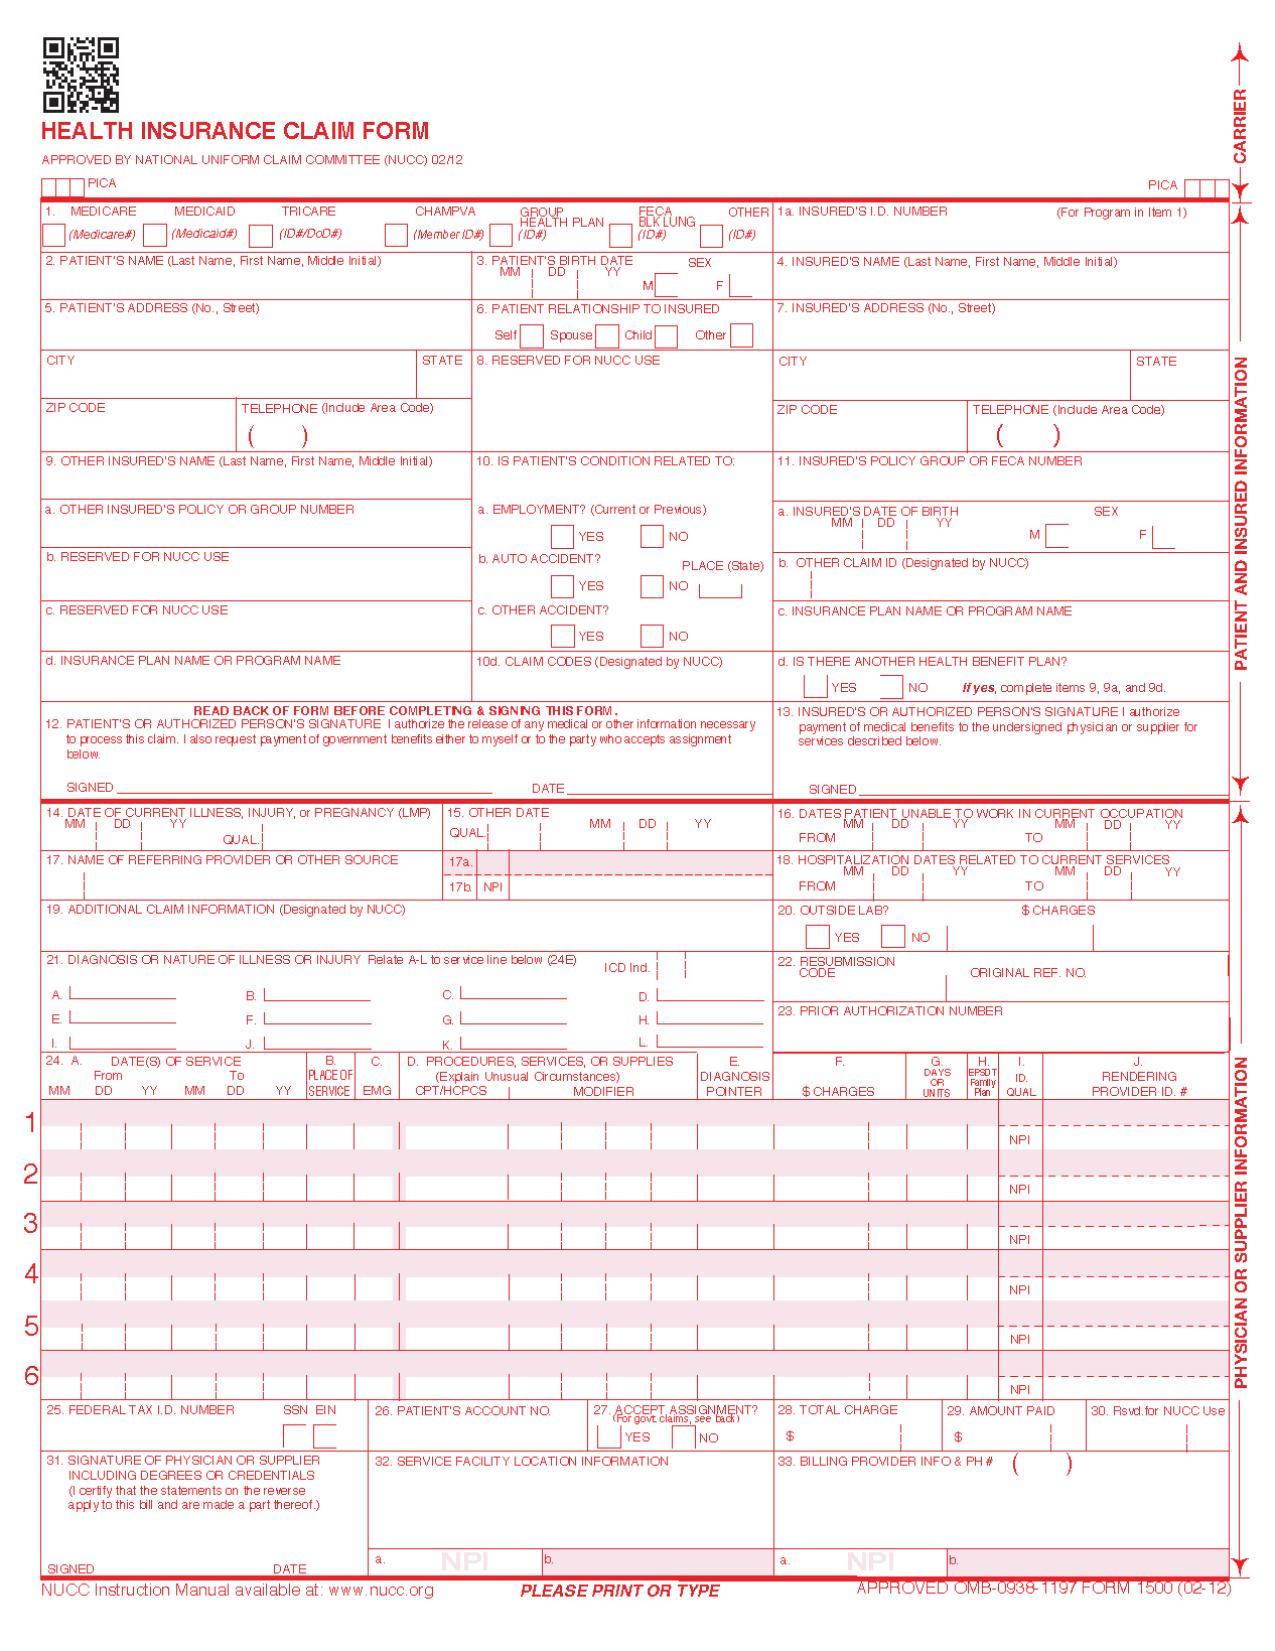


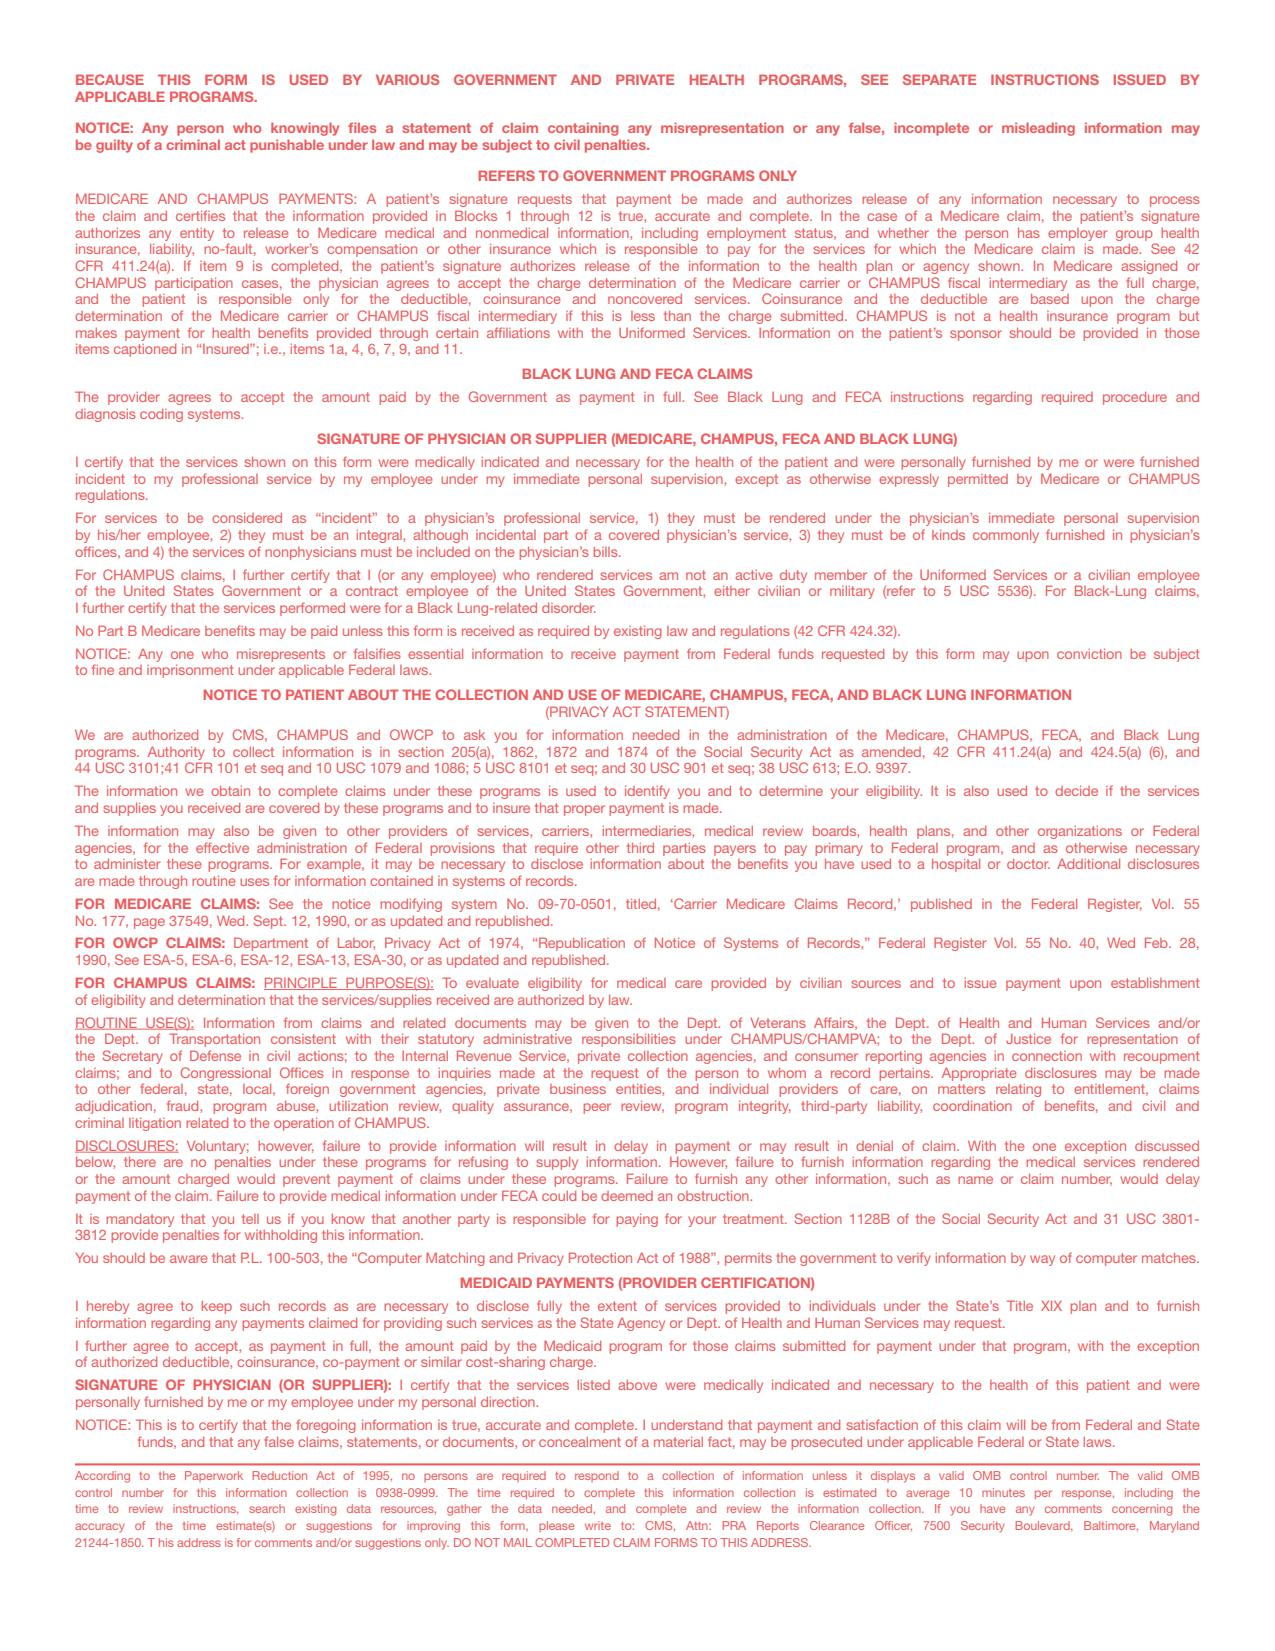


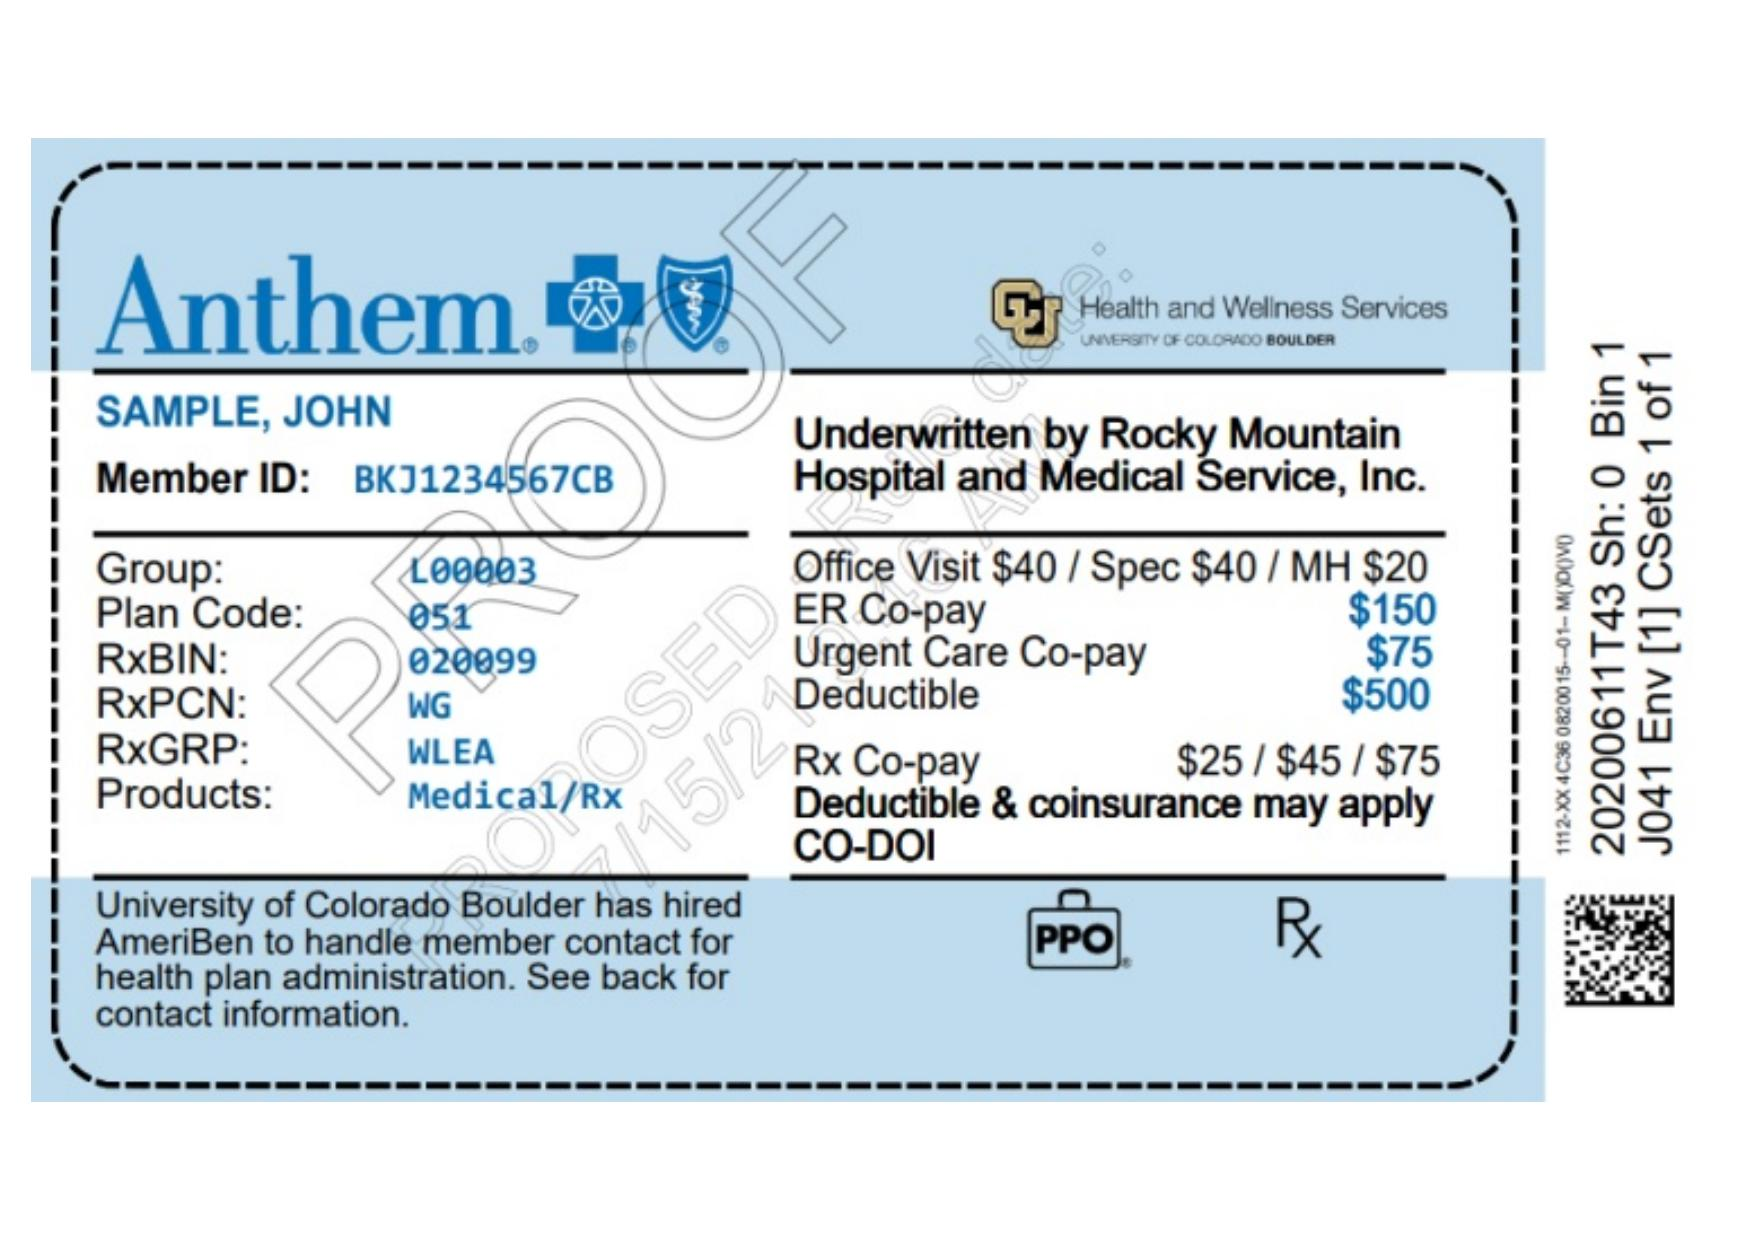


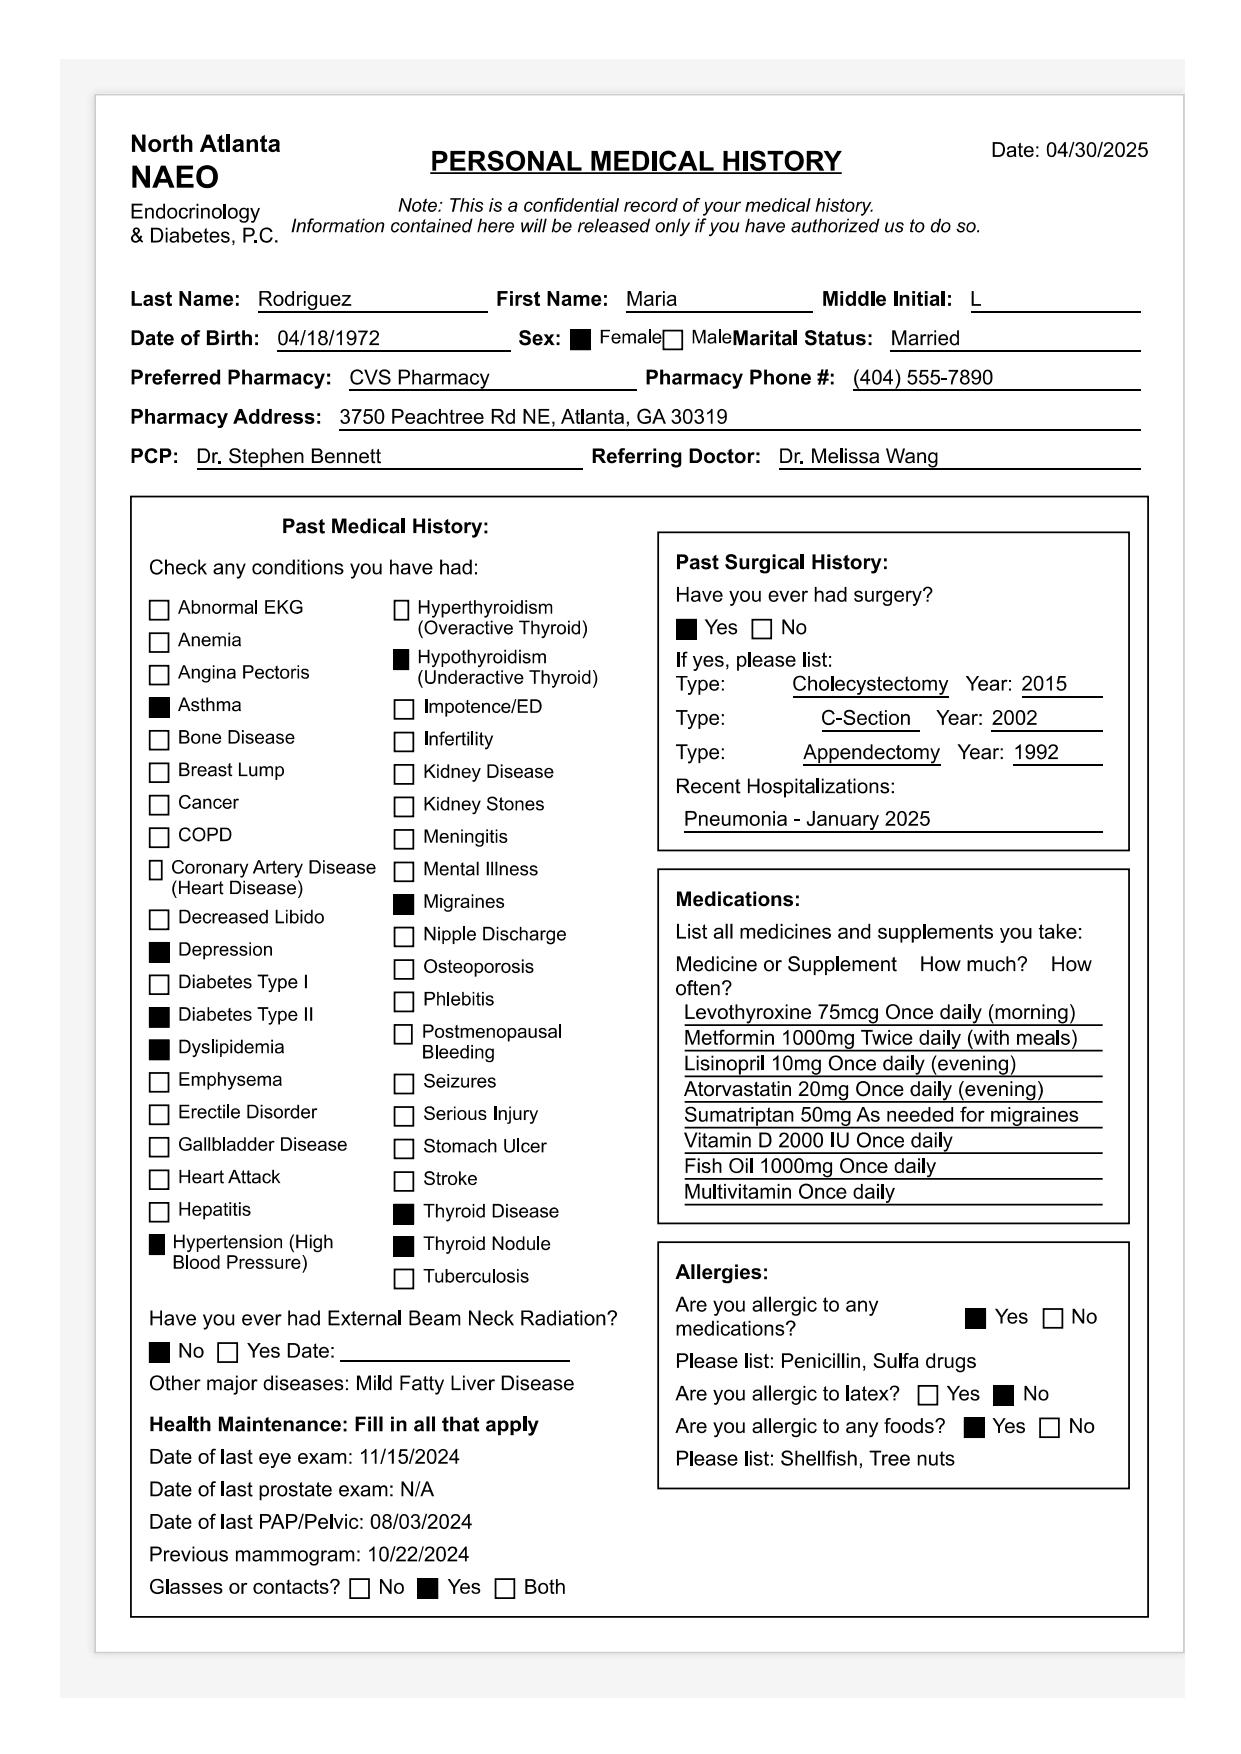


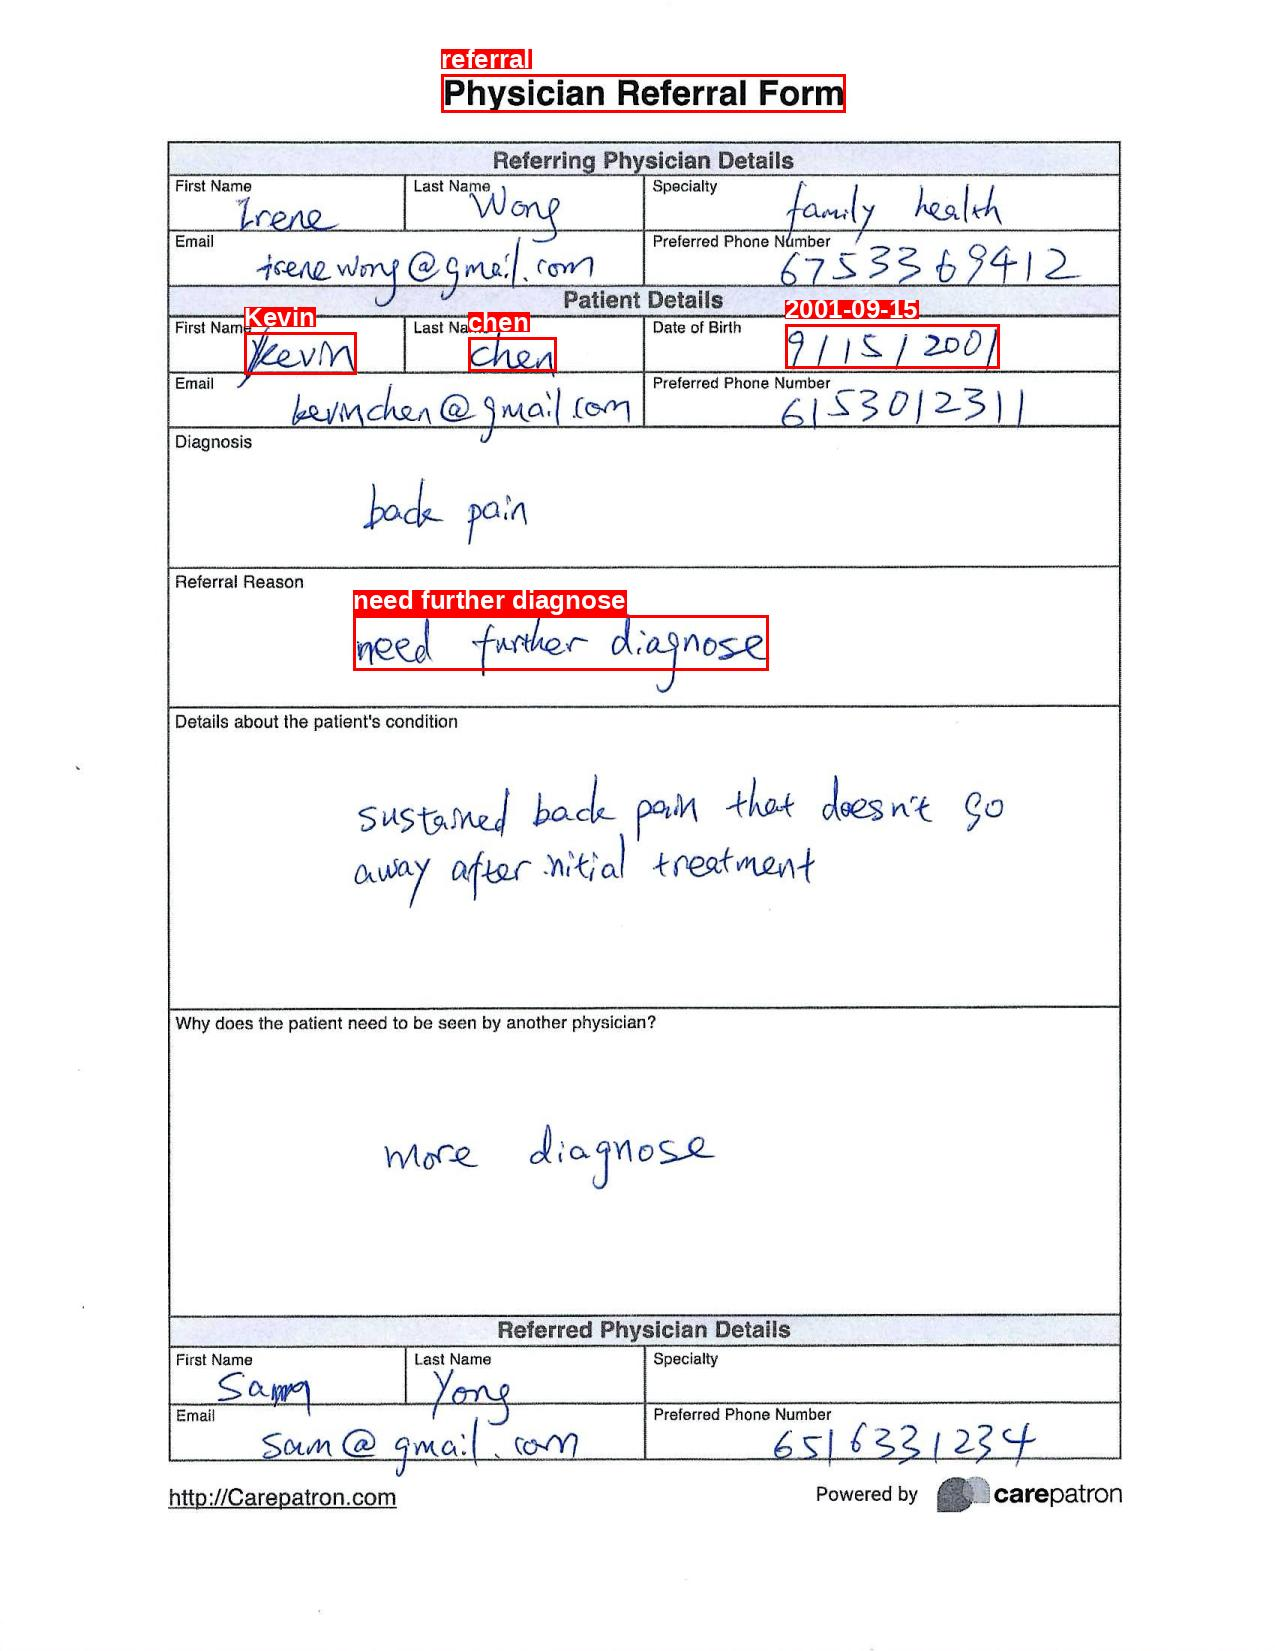

In [15]:
bboxes = collect_bboxes(payload)
print(f"Found {len(bboxes)} grounded boxes (schema={document_type!r})")

if bboxes:
    render_bboxes(bboxes, pdf_pages)
else:
    print("No bboxes found. Inspect payload above.")


### 📋 What was extracted

A readable table of each grounded field, its value, and confidence — from whichever schema was selected.


In [16]:
import re
import pandas as pd
from IPython.display import display


def show_extracted(bboxes):
    """Readable summary: one row per field with its final value and confidence."""
    rows, seen = [], set()
    for field, _page, _xywh, _label, value, conf in bboxes:
        if field in seen:
            continue
        seen.add(field)
        name = re.sub(r"^(?:[^.\[]*\[\d+\]\.)+", "", field)  # drop leading list index
        rows.append({"Field": name, "Value": "" if value is None else str(value), "Confidence": conf})
    df = pd.DataFrame(rows, columns=["Field", "Value", "Confidence"])
    return df.style.hide(axis="index").set_table_styles([
        {"selector": "th, td", "props": [("text-align", "left"), ("padding", "6px 14px"), ("font-size", "13px")]},
        {"selector": "thead th", "props": [("background", "#f1f3f4"), ("font-weight", "600")]},
    ])


if bboxes:
    display(show_extracted(bboxes))
else:
    print("Run the bbox cell above first.")


Field,Value,Confidence
data.pages[0].patient.givenName,Kevin,hi
data.pages[0].patient.familyName,chen,hi
data.pages[0].patient.dateOfBirth,2001-09-15,hi
data.pages[0].type,referral,hi
data.pages[0].reasonForReferral,need further diagnose,hi


---
## 📋 6. Summary

| | Multi-schema extraction (Orion-2) |
|---|---|
| **Call** | `client.agent.execute` (once) |
| **Model** | `vlmrun-orion-2:pro` |
| **Skill** | `medical-multi-schema-extraction` |
| **Schema selection** | Automatic — classify → load `schemas/<documentType>.json` |
| **Grounding & confidence** | Baked into the skill after the schema is selected |
| **Wait** | `executions.wait` |
| **Selection signal** | `documentType` (+ `classificationRationale`) in the response |

**The key points:**

1. You do not choose the schema up front — the skill **selects** it from the classified document type.
2. One execution handles classify + select + grounded extract.
3. Swap in a medical-record request or progress note PDF and the same call routes to a different schema automatically.
